In [365]:
# Cellule 1 — Imports

In [367]:
# ── Manipulation données ──────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Connexion SQL Server ──────────────────────────────────────
import pyodbc
print(pyodbc.drivers())

# ── Utilitaires ───────────────────────────────────────────────
import warnings
import os
from datetime import datetime
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Style global des graphes ──────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

# ── Config depuis fichier central ────────────────────────────
import sys
import importlib
sys.path.append(os.path.join("..", ))
# ← Force le rechargement du config à chaque exécution
import config
importlib.reload(config)
from config import *

OUTPUT_DIR = os.path.join("..", "..", "output", BASE_NAME, "exploration")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Imports OK")
print(f"✅ Config chargée — Base : {BASE_NAME}")
print(f"Output : {OUTPUT_DIR}")

['SQL Server', 'ODBC Driver 17 for SQL Server', 'SQL Server Native Client 11.0', 'ODBC Driver 13 for SQL Server', 'Oracle dans OraDB18Home1', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']
Imports OK
✅ Config chargée — Base : PHARMA
Output : ..\..\output\PHARMA\exploration


In [368]:
# Cellule 2 — Connexion SQL Server

In [370]:
conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SQL_SERVER};"
    f"DATABASE={SQL_DATABASE};"
    f"UID={SQL_UID};PWD={SQL_PWD};"
)
cursor = conn.cursor()
print(f"✅ Connecté à SQL Server — base de travail : {SQL_DATABASE}")
print(f"Base SAGE ciblée : {BASE_NAME}")

✅ Connecté à SQL Server — base de travail : Test
Base SAGE ciblée : PHARMA


In [371]:
# Cellule 3 — Chargement des données brutes

In [372]:
query_mvt = f"""
SELECT
    DateJour,
    AR_Ref,
    AR_Design,
    FA_CodeFamille,
    FA_Intitule,
    CL_No1, CL_Intitule1,
    CL_No2, CL_Intitule2,
    CL_No3, CL_Intitule3,
    CL_No4, CL_Intitule4,
    DE_No,
    DE_Intitule,
    TotalEntree,
    TotalSortie,
    ValeurEntree,
    ValeurSortie,
    TotalValeurMouvement
FROM Test.stock.VW_MouvementsJournaliers
WHERE BaseName = '{BASE_NAME}'
ORDER BY DateJour, AR_Ref, DE_No
"""

df_mvt = pd.read_sql(query_mvt, conn)
df_mvt['DateJour'] = pd.to_datetime(df_mvt['DateJour'])

print(f"Mouvements chargés : {len(df_mvt):,} lignes")
print(f"📅 Période : {df_mvt['DateJour'].min().date()}  →  {df_mvt['DateJour'].max().date()}")

Mouvements chargés : 101,512 lignes
📅 Période : 2024-01-01  →  2026-06-10


In [373]:
query_stock = f"""
SELECT
    DateJour,
    AR_Ref,
    AR_Design,
    FA_CodeFamille,
    FA_Intitule,
    CL_No1, CL_Intitule1,
    DE_No,
    DE_Intitule,
    TotalEntree,
    TotalSortie,
    ValeurEntree,
    ValeurSortie,
    StockInitial,
    StockFinal,
    ValeurInitiale,
    ValeurFinale
FROM Test.stock.StockJournalierCache
WHERE BaseName = '{BASE_NAME}'
ORDER BY DateJour, AR_Ref, DE_No
"""

df_stock = pd.read_sql(query_stock, conn)
df_stock['DateJour'] = pd.to_datetime(df_stock['DateJour'])

print(f"Stock journalier chargé : {len(df_stock):,} lignes")

Stock journalier chargé : 101,512 lignes


In [374]:
# Cellule 4 — Aperçu général des données

In [375]:
print("=" * 60)
print(f"  DATASET : VW_MouvementsJournaliers — {BASE_NAME}")
print("=" * 60)
print(f"\n  Lignes        : {len(df_mvt):,}")
print(f"  Colonnes      : {df_mvt.shape[1]}")
print(f"  Période       : {df_mvt['DateJour'].min().date()} → {df_mvt['DateJour'].max().date()}")
print(f"  Nb articles   : {df_mvt['AR_Ref'].nunique():,}")
print(f"  Nb dépôts     : {df_mvt['DE_No'].nunique()}")
print(f"  Nb familles   : {df_mvt['FA_CodeFamille'].nunique()}")
print(f"  Nb jours      : {df_mvt['DateJour'].nunique():,}")

  DATASET : VW_MouvementsJournaliers — PHARMA

  Lignes        : 101,512
  Colonnes      : 20
  Période       : 2024-01-01 → 2026-06-10
  Nb articles   : 154
  Nb dépôts     : 3
  Nb familles   : 10
  Nb jours      : 892


In [376]:
# Aperçu des 5 premières lignes
df_mvt.head()

,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,CL_No1,CL_Intitule1,CL_No2,CL_Intitule2,CL_No3,CL_Intitule3,CL_No4,CL_Intitule4,DE_No,DE_Intitule,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,TotalValeurMouvement
0,2024-01-01,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,1,Maroc Nord,10,Générique,20,Boîte 10,30,Officine,1,Dépôt Central Casablanca,1063.0,27.3401,334540.3442,8836.798772,325703.545428
1,2024-01-01,PH0002,Ciprofloxacine 500mg,ANALG,Analgésiques,2,Maroc Centre,11,Original,21,Boîte 30,31,Clinique,2,Dépôt Rabat,709.0,6.7414,92176.5937,872.002112,91304.591588
2,2024-01-01,PH0003,Azithromycine 250mg,CARDIO,Cardiologie,3,Maroc Sud,12,OTC,22,Boîte 100,32,Hôpital,3,Dépôt Marrakech,1709.0,30.5728,559243.7605,9566.758029,549677.002471
3,2024-01-01,PH0004,Doxycycline 100mg,DIAB,Diabétologie,4,Export,13,Hospitalier,23,Flacon,30,Officine,1,Dépôt Central Casablanca,691.0,23.1182,150325.6680,4973.945461,145351.722539
4,2024-01-01,PH0005,Métronidazole 250mg,DERMA,Dermatologie,1,Maroc Nord,10,Générique,20,Boîte 10,31,Clinique,2,Dépôt Rabat,1649.0,20.2243,189940.2299,2198.219616,187742.010284


In [377]:
# Aperçu des 5 deriniere lignes
df_mvt.tail()

,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,CL_No1,CL_Intitule1,CL_No2,CL_Intitule2,CL_No3,CL_Intitule3,CL_No4,CL_Intitule4,DE_No,DE_Intitule,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,TotalValeurMouvement
101507,2026-06-10,PH0150,Ginseng Extrait,VITAM,Vitamines & Compléments,2,Maroc Centre,11,Original,21,Boîte 30,32,Hôpital,3,Dépôt Marrakech,0.0,2.2227,0.0,518.572803,-518.572803
101508,2026-06-10,PH0151,Vancomycine 500mg Inj.,ANTIB,Antibiotiques,3,Maroc Sud,12,OTC,22,Boîte 100,30,Officine,1,Dépôt Central Casablanca,0.0,1.4955,0.0,77.292375,-77.292375
101509,2026-06-10,PH0152,Linézolide 600mg,ANALG,Analgésiques,4,Export,13,Hospitalier,23,Flacon,31,Clinique,2,Dépôt Rabat,0.0,6.5157,0.0,2578.684056,-2578.684056
101510,2026-06-10,PH0153,Méropénème 1g Inj.,CARDIO,Cardiologie,1,Maroc Nord,10,Générique,20,Boîte 10,32,Hôpital,3,Dépôt Marrakech,0.0,3.2062,0.0,528.092561,-528.092561
101511,2026-06-10,PH0154,Pipéracilline+Tazobactam,DIAB,Diabétologie,2,Maroc Centre,11,Original,21,Boîte 30,30,Officine,1,Dépôt Central Casablanca,0.0,6.0514,0.0,139.778263,-139.778263


In [378]:
# Types et mémoire
df_mvt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101512 entries, 0 to 101511
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   DateJour              101512 non-null  datetime64[ns]
 1   AR_Ref                101512 non-null  object        
 2   AR_Design             101512 non-null  object        
 3   FA_CodeFamille        101512 non-null  object        
 4   FA_Intitule           101512 non-null  object        
 5   CL_No1                101512 non-null  int64         
 6   CL_Intitule1          101512 non-null  object        
 7   CL_No2                101512 non-null  int64         
 8   CL_Intitule2          101512 non-null  object        
 9   CL_No3                101512 non-null  int64         
 10  CL_Intitule3          101512 non-null  object        
 11  CL_No4                101512 non-null  int64         
 12  CL_Intitule4          101512 non-null  object        
 13 

In [379]:
# Statistiques descriptives — colonnes numériques
df_mvt[['TotalEntree','TotalSortie','ValeurEntree','ValeurSortie','TotalValeurMouvement']]\
    .describe()\
    .round(2)

,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,TotalValeurMouvement
count,101512.00,101512.00,101512.00,101512.00,101512.00
mean,11.93,11.52,2892.30,2673.99,218.31
std,86.96,9.46,24180.26,3062.77,24121.83
min,0.00,0.00,0.00,0.00,-27980.71
25%,0.00,4.49,0.00,642.12,-3424.86
50%,0.00,8.22,0.00,1615.52,-1533.92
75%,0.00,16.38,0.00,3536.01,-585.74
max,1993.00,68.13,911586.09,28454.09,898809.64


In [380]:
# Cellule 5 — Description & types des colonnes

In [381]:
desc = {
    'DateJour'             : ('DATE',         'Date du mouvement (journalier)'),
    'AR_Ref'               : ('NVARCHAR(50)',  'Référence article SAGE'),
    'AR_Design'            : ('NVARCHAR(255)', 'Désignation article'),
    'FA_CodeFamille'       : ('NVARCHAR(10)',  'Code famille article'),
    'FA_Intitule'          : ('NVARCHAR(255)', 'Libellé famille'),
    'CL_No1 / CL_Intitule1': ('INT / NVARCHAR','Catalogue niveau 1'),
    'CL_No2 / CL_Intitule2': ('INT / NVARCHAR','Catalogue niveau 2'),
    'CL_No3 / CL_Intitule3': ('INT / NVARCHAR','Catalogue niveau 3'),
    'CL_No4 / CL_Intitule4': ('INT / NVARCHAR','Catalogue niveau 4'),
    'DE_No'                : ('INT',           'Numéro dépôt'),
    'DE_Intitule'          : ('NVARCHAR(255)', 'Nom du dépôt'),
    'TotalEntree'          : ('DECIMAL(18,4)', 'Quantité totale entrée du jour'),
    'TotalSortie'          : ('DECIMAL(18,4)', 'Quantité totale sortie du jour'),
    'ValeurEntree'         : ('DECIMAL(18,4)', 'Valeur entrée (qté × DL_PrixRU)'),
    'ValeurSortie'         : ('DECIMAL(18,4)', 'Valeur sortie (qté × DL_PrixRU)'),
    'TotalValeurMouvement' : ('DECIMAL(18,4)', 'Valeur nette = ValeurEntree − ValeurSortie'),
}

df_desc = pd.DataFrame(
    [(col, t, d) for col, (t, d) in desc.items()],
    columns=['Colonne', 'Type SQL', 'Description']
)
df_desc

,Colonne,Type SQL,Description
0,DateJour,DATE,Date du mouvement (journalier)
1,AR_Ref,NVARCHAR(50),Référence article SAGE
2,AR_Design,NVARCHAR(255),Désignation article
3,FA_CodeFamille,NVARCHAR(10),Code famille article
4,FA_Intitule,NVARCHAR(255),Libellé famille
5,CL_No1 / CL_Intitule1,INT / NVARCHAR,Catalogue niveau 1
6,CL_No2 / CL_Intitule2,INT / NVARCHAR,Catalogue niveau 2
7,CL_No3 / CL_Intitule3,INT / NVARCHAR,Catalogue niveau 3
8,CL_No4 / CL_Intitule4,INT / NVARCHAR,Catalogue niveau 4
9,DE_No,INT,Numéro dépôt


In [382]:
# Cellule 6 — Valeurs manquantes 

In [383]:
missing = df_mvt.isnull().sum().reset_index()
missing.columns = ['Colonne', 'Valeurs manquantes']
missing['% manquant'] = (missing['Valeurs manquantes'] / len(df_mvt) * 100).round(2)
missing = missing[missing['Valeurs manquantes'] > 0].sort_values('% manquant', ascending=False)

if missing.empty:
    print("✅ Aucune valeur manquante dans VW_MouvementsJournaliers")
else:
    print(f"⚠️  {len(missing)} colonnes avec valeurs manquantes :\n")
    display(missing)

✅ Aucune valeur manquante dans VW_MouvementsJournaliers


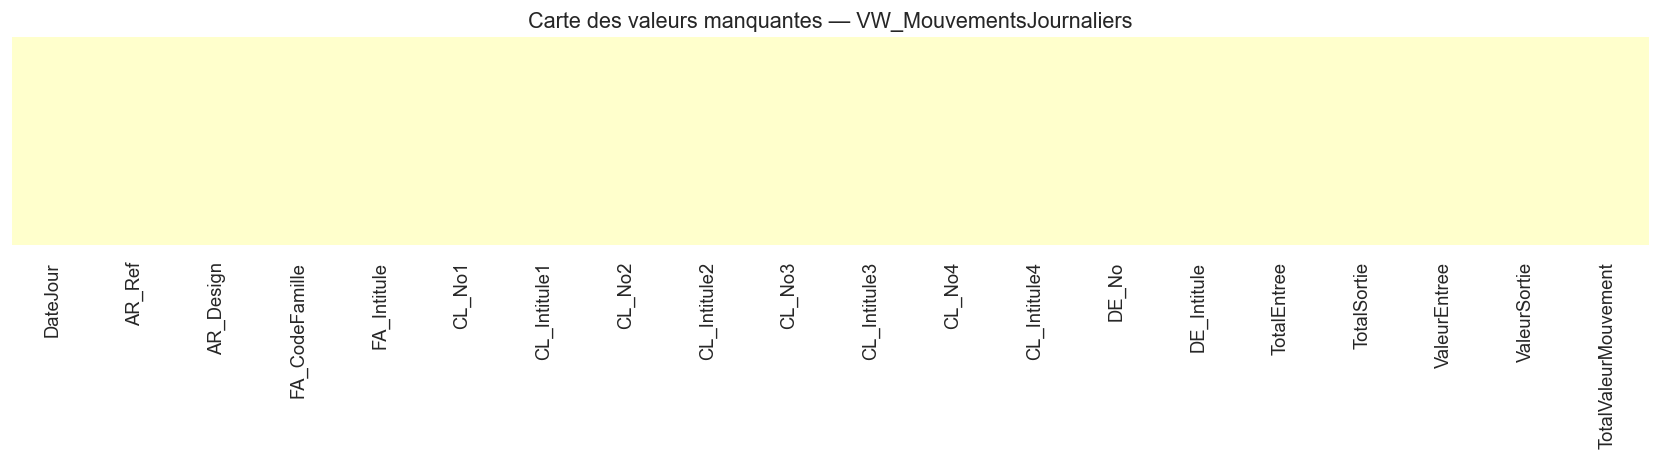

In [384]:
# Heatmap valeurs manquantes
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    df_mvt.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='YlOrRd',
    ax=ax
)
ax.set_title("Carte des valeurs manquantes — VW_MouvementsJournaliers", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}missing_values_heatmap.png")
plt.show()

In [385]:
# Cellule 7 — Valeurs aberrantes (outliers)

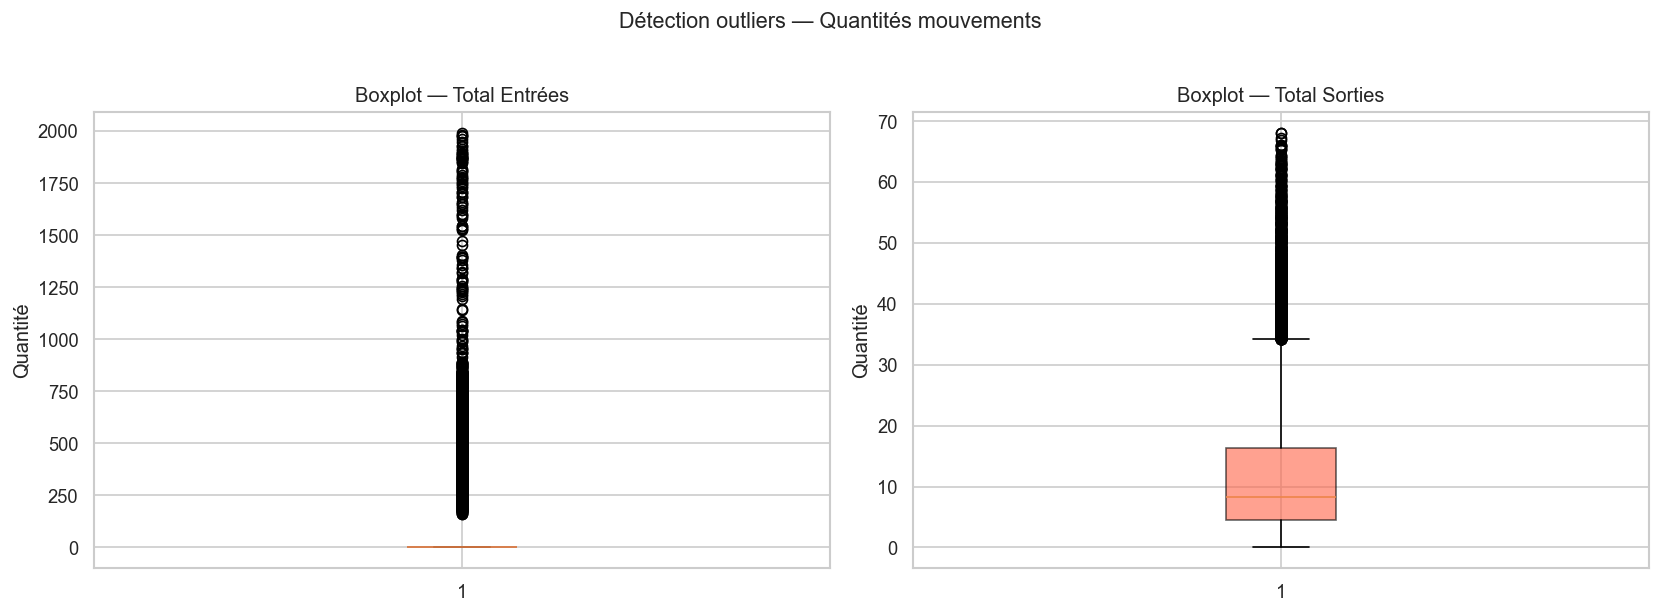

In [386]:
# ── Boxplot quantités entrées / sorties ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color in zip(
    axes,
    ['TotalEntree', 'TotalSortie'],
    ['Total Entrées', 'Total Sorties'],
    ['steelblue', 'tomato']
):
    ax.boxplot(df_mvt[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f"Boxplot — {label}", fontsize=12)
    ax.set_ylabel("Quantité")

plt.suptitle("Détection outliers — Quantités mouvements", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}outliers_boxplot_quantites.png")
plt.show()

In [387]:
# ── Méthode IQR — identification des lignes aberrantes ───────
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

for col in ['TotalEntree', 'TotalSortie', 'ValeurEntree', 'ValeurSortie']:
    out, lo, hi = detect_outliers_iqr(df_mvt, col)
    print(f"  {col:25s} → {len(out):4d} outliers  |  seuil bas: {lo:.1f}  |  seuil haut: {hi:.1f}")

  TotalEntree               → 2522 outliers  |  seuil bas: 0.0  |  seuil haut: 0.0
  TotalSortie               → 3206 outliers  |  seuil bas: -13.4  |  seuil haut: 34.2
  ValeurEntree              → 2522 outliers  |  seuil bas: 0.0  |  seuil haut: 0.0
  ValeurSortie              → 7104 outliers  |  seuil bas: -3698.7  |  seuil haut: 7876.8


In [388]:
# ── Top 10 lignes les plus aberrantes sur TotalSortie ────────
_, _, upper_s = detect_outliers_iqr(df_mvt, 'TotalSortie')

df_mvt[df_mvt['TotalSortie'] > upper_s]\
    .sort_values('TotalSortie', ascending=False)\
    [['DateJour','AR_Ref','AR_Design','DE_Intitule','TotalSortie','ValeurSortie']]\
    .head(10)\
    .reset_index(drop=True)

,DateJour,AR_Ref,AR_Design,DE_Intitule,TotalSortie,ValeurSortie
0,2025-11-12,PH0031,Oméprazole 20mg,Dépôt Central Casablanca,68.1275,8949.909675
1,2026-02-03,PH0106,Codéine Sirop,Dépôt Central Casablanca,67.9819,22348.696119
2,2025-11-24,PH0121,Rétinoïde Gel 0.025%,Dépôt Central Casablanca,67.2894,1541.431931
3,2024-02-22,PH0151,Vancomycine 500mg Inj.,Dépôt Central Casablanca,66.8340,0.000000
4,2026-02-07,PH0031,Oméprazole 20mg,Dépôt Central Casablanca,66.0478,8187.866509
5,2025-01-14,PH0101,Nitrofurantoïne 100mg,Dépôt Rabat,66.0342,25212.207541
6,2024-01-13,PH0026,Salbutamol Spray,Dépôt Rabat,65.9828,26566.892302
7,2024-11-02,PH0031,Oméprazole 20mg,Dépôt Central Casablanca,65.8526,7845.145358
8,2025-02-05,PH0101,Nitrofurantoïne 100mg,Dépôt Rabat,65.7286,27521.563895
9,2024-01-02,PH0121,Rétinoïde Gel 0.025%,Dépôt Central Casablanca,65.4183,1538.226281


In [389]:
#Cellule 8 — Distribution des quantités

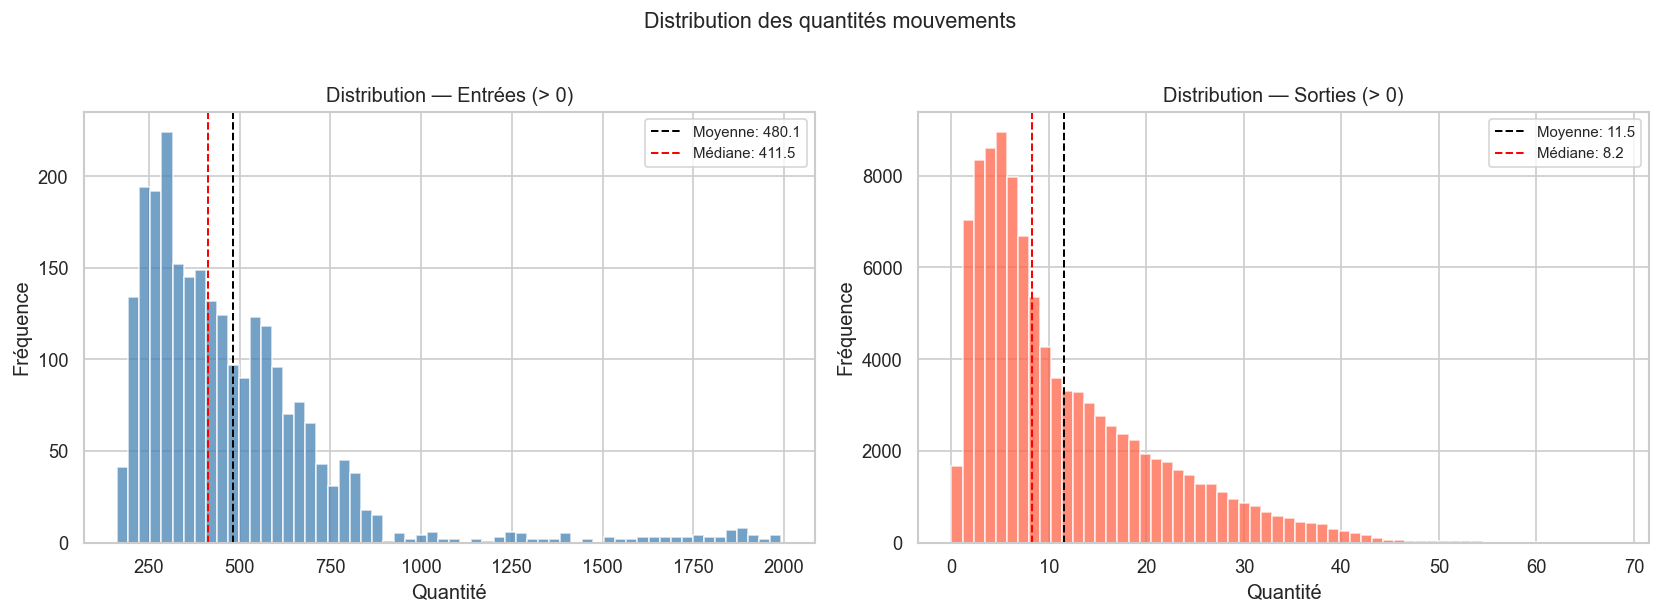

In [390]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in zip(
    axes,
    ['TotalEntree', 'TotalSortie'],
    ['steelblue', 'tomato'],
    ['Entrées', 'Sorties']
):
    data = df_mvt[df_mvt[col] > 0][col]
    ax.hist(data, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Moyenne: {data.mean():.1f}')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'Médiane: {data.median():.1f}')
    ax.set_title(f"Distribution — {label} (> 0)", fontsize=12)
    ax.set_xlabel("Quantité")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=9)

plt.suptitle("Distribution des quantités mouvements", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}distribution_quantites.png")
plt.show()

In [391]:
# Cellule 9 — Évolution temporelle globale

In [392]:
# ── Agrégation journalière toutes bases ──────────────────────
df_daily = df_mvt.groupby('DateJour').agg(
    TotalEntree   = ('TotalEntree',  'sum'),
    TotalSortie   = ('TotalSortie',  'sum'),
    ValeurEntree  = ('ValeurEntree', 'sum'),
    ValeurSortie  = ('ValeurSortie', 'sum'),
    NbArticles    = ('AR_Ref',       'nunique')
).reset_index()

df_daily.tail()

,DateJour,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,NbArticles
887,2026-06-06,1684.0,1398.4241,315270.8586,323973.282984,130
888,2026-06-07,0.0,454.6208,0.0000,101589.386105,42
889,2026-06-08,3428.0,1513.7694,635348.1149,337306.804150,131
890,2026-06-09,1969.0,1590.9550,404663.7827,329374.726658,140
891,2026-06-10,2156.0,1628.9364,834614.7235,370746.970572,141


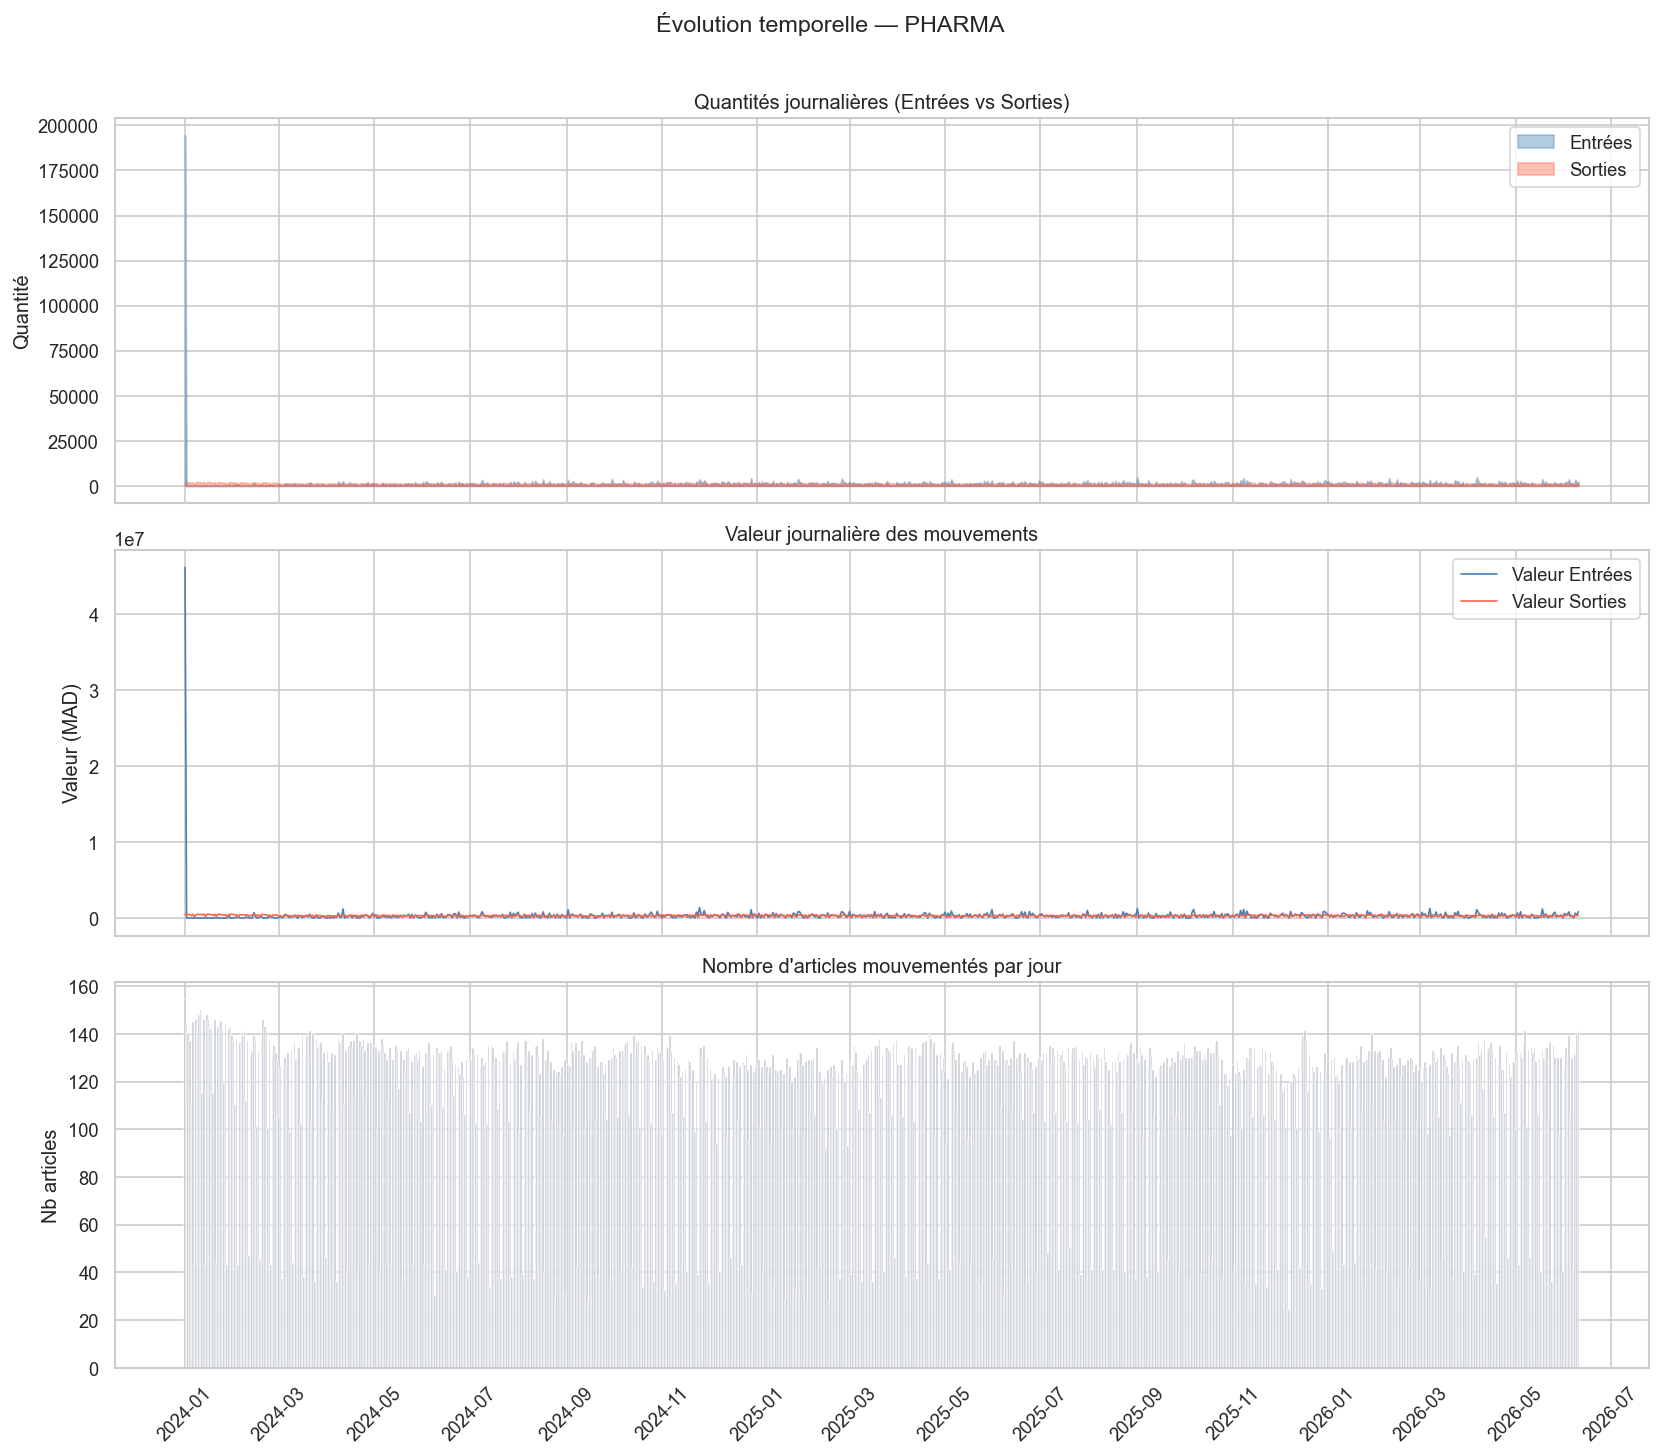

In [393]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ── Quantités ────────────────────────────────────────────────
axes[0].fill_between(df_daily['DateJour'], df_daily['TotalEntree'],
                     alpha=0.4, color='steelblue', label='Entrées')
axes[0].fill_between(df_daily['DateJour'], df_daily['TotalSortie'],
                     alpha=0.4, color='tomato', label='Sorties')
axes[0].set_title("Quantités journalières (Entrées vs Sorties)", fontsize=12)
axes[0].legend()
axes[0].set_ylabel("Quantité")

# ── Valeurs ───────────────────────────────────────────────────
axes[1].plot(df_daily['DateJour'], df_daily['ValeurEntree'],
             color='steelblue', linewidth=1, label='Valeur Entrées')
axes[1].plot(df_daily['DateJour'], df_daily['ValeurSortie'],
             color='tomato', linewidth=1, label='Valeur Sorties')
axes[1].set_title("Valeur journalière des mouvements", fontsize=12)
axes[1].legend()
axes[1].set_ylabel("Valeur (MAD)")

# ── Nb articles actifs ────────────────────────────────────────
axes[2].bar(df_daily['DateJour'], df_daily['NbArticles'],
            color='slategray', alpha=0.6, width=1)
axes[2].set_title("Nombre d'articles mouvementés par jour", fontsize=12)
axes[2].set_ylabel("Nb articles")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.suptitle(f"Évolution temporelle — {BASE_NAME}", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}evolution_temporelle.png")
plt.show()

In [394]:
# Cellule 10 — Saisonnalité (mois / jour de semaine)

In [395]:
df_mvt['Mois']       = df_mvt['DateJour'].dt.month
df_mvt['Annee']      = df_mvt['DateJour'].dt.year
df_mvt['JourSemaine'] = df_mvt['DateJour'].dt.dayofweek  # 0=Lundi
df_mvt['NomJour']    = df_mvt['DateJour'].dt.day_name()

jours_ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mois_labels  = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

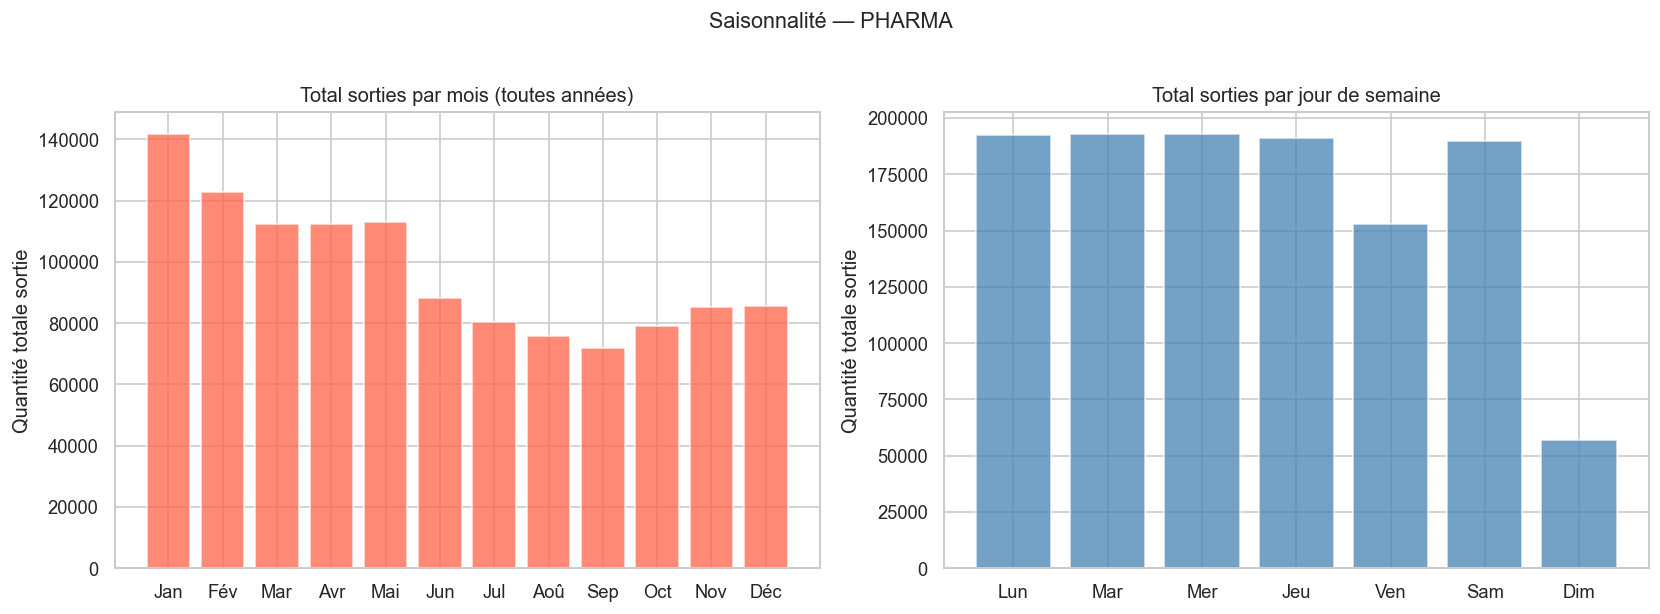

In [396]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Par mois ─────────────────────────────────────────────────
by_mois = df_mvt.groupby('Mois')['TotalSortie'].sum()
axes[0].bar(by_mois.index, by_mois.values, color='tomato', alpha=0.75)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(mois_labels)
axes[0].set_title("Total sorties par mois (toutes années)", fontsize=12)
axes[0].set_ylabel("Quantité totale sortie")

# ── Par jour de semaine ───────────────────────────────────────
by_jour = df_mvt.groupby('NomJour')['TotalSortie'].sum().reindex(jours_ordre)
axes[1].bar(by_jour.index, by_jour.values, color='steelblue', alpha=0.75)
axes[1].set_xticklabels(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'])
axes[1].set_title("Total sorties par jour de semaine", fontsize=12)
axes[1].set_ylabel("Quantité totale sortie")

plt.suptitle(f"Saisonnalité — {BASE_NAME}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}saisonnalite.png")
plt.show()

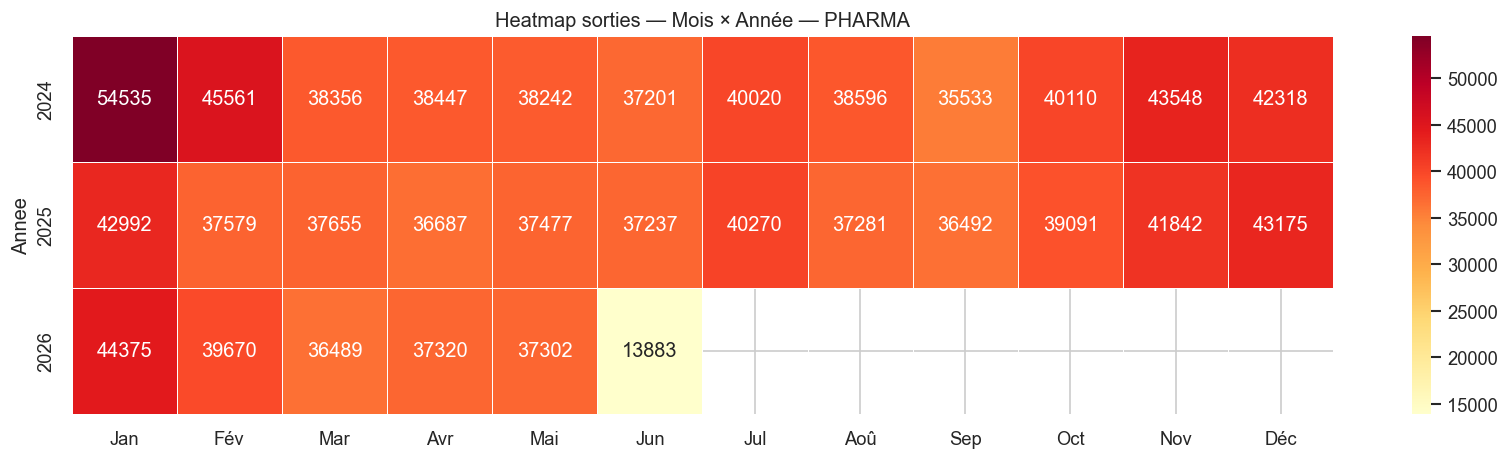

In [397]:
# ── Heatmap mois × année ─────────────────────────────────────
pivot_mois = df_mvt.pivot_table(
    values='TotalSortie',
    index='Annee',
    columns='Mois',
    aggfunc='sum'
)
pivot_mois.columns = mois_labels[:len(pivot_mois.columns)]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_mois, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax)
ax.set_title(f"Heatmap sorties — Mois × Année — {BASE_NAME}", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}heatmap_mois_annee.png")
plt.show()

In [398]:
# Cellule 11 — Analyse par famille d'articles

In [399]:
by_famille = df_mvt.groupby(['FA_CodeFamille','FA_Intitule']).agg(
    TotalSortie  = ('TotalSortie',  'sum'),
    TotalEntree  = ('TotalEntree',  'sum'),
    ValeurSortie = ('ValeurSortie', 'sum'),
    NbJours      = ('DateJour',     'nunique'),
    NbArticles   = ('AR_Ref',       'nunique')
).reset_index().sort_values('TotalSortie', ascending=False)

by_famille.head(15)

,FA_CodeFamille,FA_Intitule,TotalSortie,TotalEntree,ValeurSortie,NbJours,NbArticles
2,CARDIO,Cardiologie,134861.4503,138829.0,3.016930e+07,890,16
1,ANTIB,Antibiotiques,133249.7883,136940.0,2.409201e+07,888,16
8,RESP,Respiratoire,127956.8920,131899.0,3.219083e+07,891,15
3,DERMA,Dermatologie,122046.5234,125719.0,2.742656e+07,889,15
5,GASTRO,Gastro-entérologie,119381.1197,123919.0,2.919666e+07,890,15
7,OPHTA,Ophtalmologie,113058.5060,118934.0,2.439173e+07,892,15
9,VITAM,Vitamines & Compléments,109596.8433,114624.0,3.046171e+07,889,15
6,NEURO,Neurologie,107137.7268,110330.0,2.354769e+07,891,15
4,DIAB,Diabétologie,106988.4920,110662.0,2.841667e+07,891,16
0,ANALG,Analgésiques,95004.3479,99053.0,2.154927e+07,891,16


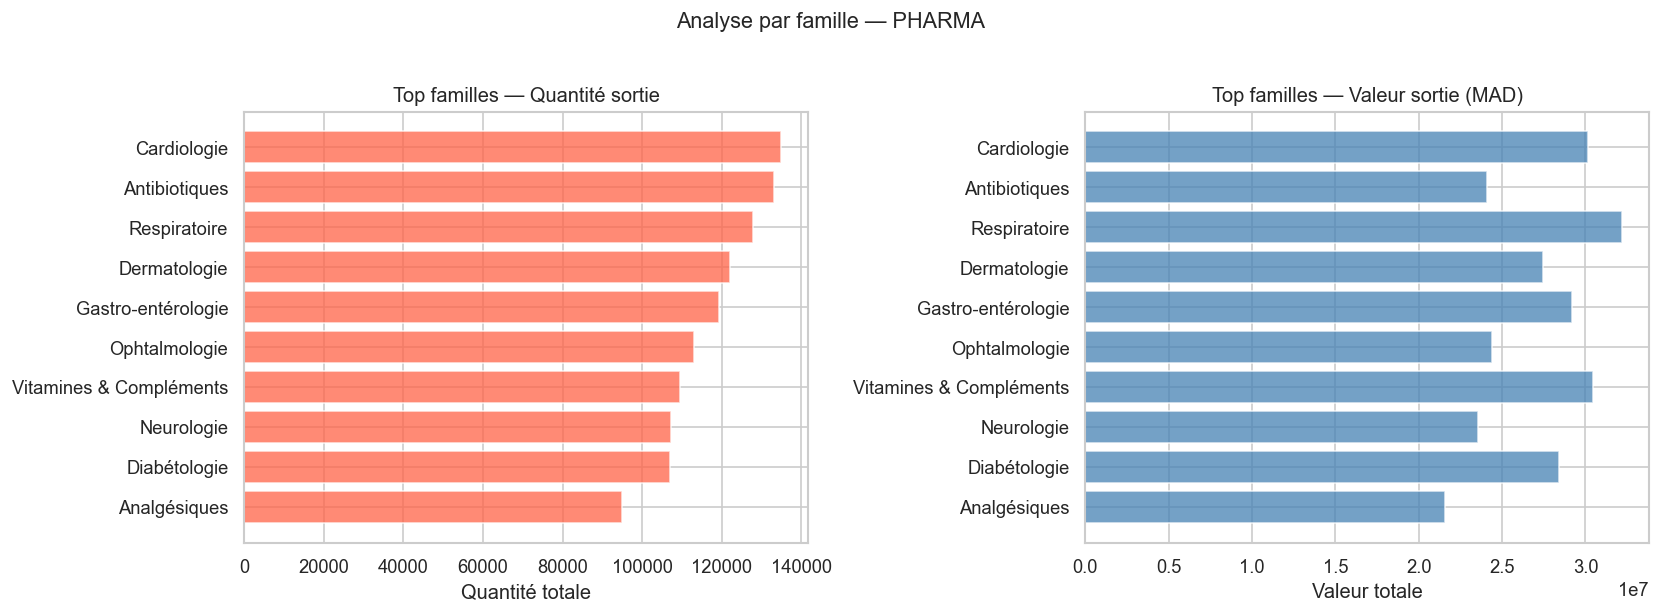

In [400]:
top_fam = by_famille.head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Par quantité ──────────────────────────────────────────────
axes[0].barh(top_fam['FA_Intitule'], top_fam['TotalSortie'],
             color='tomato', alpha=0.75)
axes[0].invert_yaxis()
axes[0].set_title("Top familles — Quantité sortie", fontsize=12)
axes[0].set_xlabel("Quantité totale")

# ── Par valeur ────────────────────────────────────────────────
axes[1].barh(top_fam['FA_Intitule'], top_fam['ValeurSortie'],
             color='steelblue', alpha=0.75)
axes[1].invert_yaxis()
axes[1].set_title("Top familles — Valeur sortie (MAD)", fontsize=12)
axes[1].set_xlabel("Valeur totale")

plt.suptitle(f"Analyse par famille — {BASE_NAME}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}top_familles.png")
plt.show()

In [401]:
# Cellule 12 — Top articles les plus mouvementés

In [402]:
by_article = df_mvt.groupby(['AR_Ref','AR_Design']).agg(
    TotalSortie   = ('TotalSortie',   'sum'),
    TotalEntree   = ('TotalEntree',   'sum'),
    ValeurSortie  = ('ValeurSortie',  'sum'),
    NbJoursSortie = ('DateJour',      'nunique'),
    MoyenneSortie = ('TotalSortie',   'mean')
).reset_index().sort_values('TotalSortie', ascending=False)

print(f"Nombre total d'articles distincts : {len(by_article):,}")
by_article.head(20)

Nombre total d'articles distincts : 154


,AR_Ref,AR_Design,TotalSortie,TotalEntree,ValeurSortie,NbJoursSortie,MoyenneSortie
88,PH0089,Carbamazépine 200mg,14548.2821,14947.0,4.005788e+06,691,21.053954
84,PH0085,Cholestyramine Sachet,14502.3770,15213.0,6.444238e+06,659,22.006642
115,PH0116,Glibenclamide 5mg,14327.8244,14556.0,6.006268e+06,658,21.774809
40,PH0041,Chloramphénicol Collyre,14318.1777,14433.0,1.182632e+06,667,21.466533
4,PH0005,Métronidazole 250mg,13950.4101,14184.0,1.534812e+06,674,20.697938
102,PH0103,Pivmécillinam 200mg,13861.1955,14487.0,8.813825e+05,664,20.875294
10,PH0011,Amlodipine 5mg,13790.4429,14266.0,7.417093e+05,670,20.582751
15,PH0016,Metformine 850mg,13756.7146,14029.0,1.349915e+06,646,21.295224
49,PH0050,Magnésium 300mg,13692.7131,14263.0,4.685711e+06,628,21.803683
111,PH0112,Aténolol 50mg,13533.9236,13621.0,2.159055e+05,650,20.821421


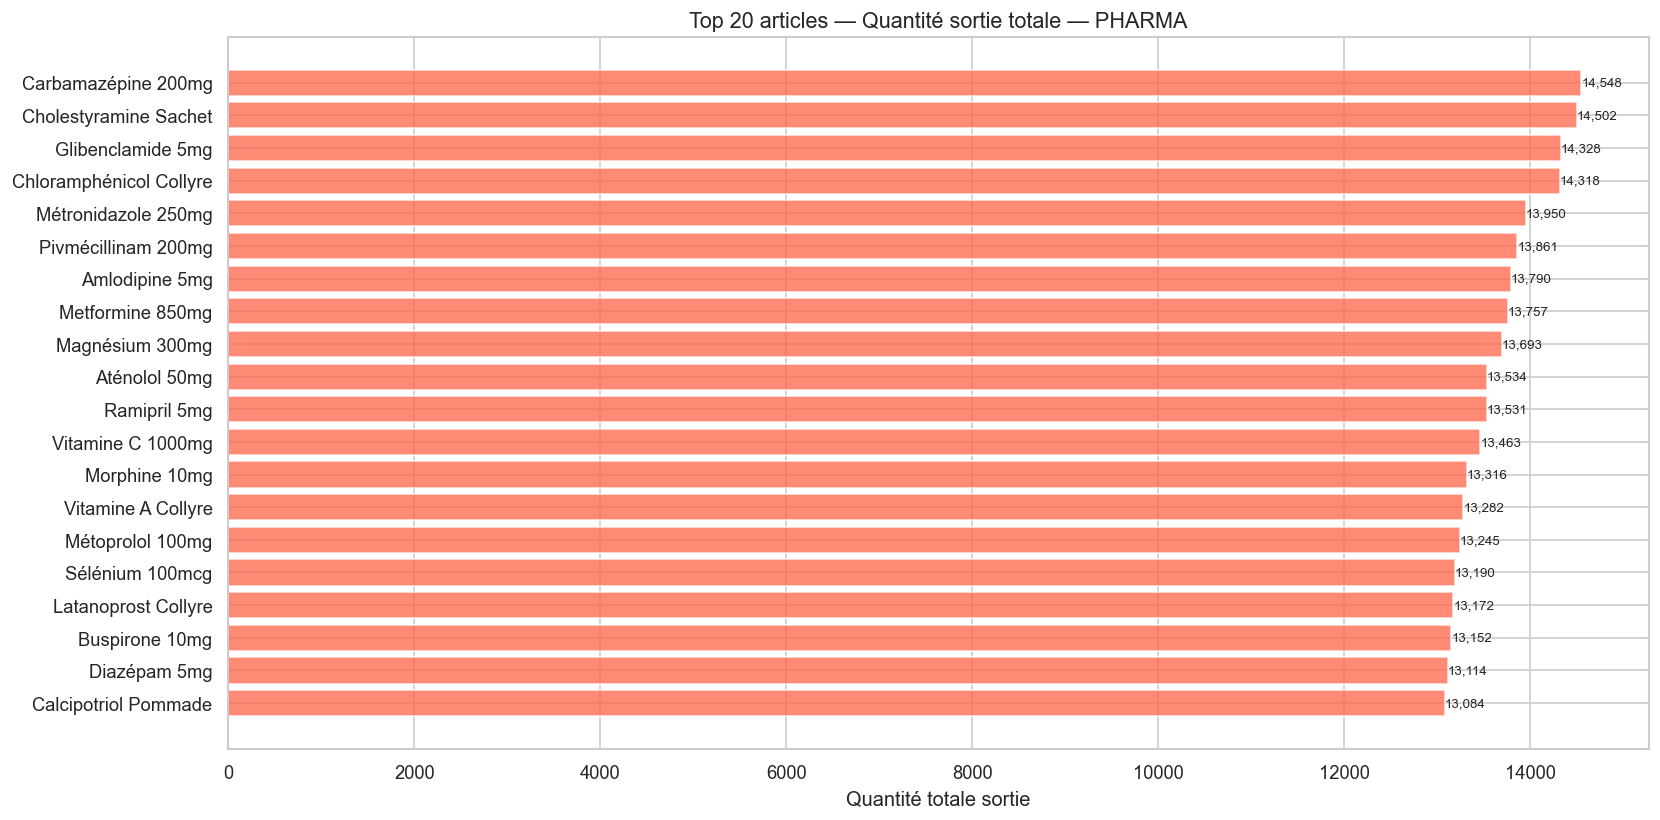

In [403]:
top20 = by_article.head(20)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top20['AR_Design'], top20['TotalSortie'],
               color='tomato', alpha=0.75)
ax.invert_yaxis()
ax.set_title(f"Top 20 articles — Quantité sortie totale — {BASE_NAME}", fontsize=13)
ax.set_xlabel("Quantité totale sortie")

for bar, val in zip(bars, top20['TotalSortie']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}top20_articles.png")
plt.show()

In [404]:
# Cellule 13 — Analyse par dépôt

In [405]:
by_depot = df_mvt.groupby(['DE_No','DE_Intitule']).agg(
    TotalSortie  = ('TotalSortie',  'sum'),
    TotalEntree  = ('TotalEntree',  'sum'),
    ValeurSortie = ('ValeurSortie', 'sum'),
    NbArticles   = ('AR_Ref',       'nunique'),
    NbJours      = ('DateJour',     'nunique')
).reset_index().sort_values('TotalSortie', ascending=False)

by_depot

,DE_No,DE_Intitule,TotalSortie,TotalEntree,ValeurSortie,NbArticles,NbJours
0,1,Dépôt Central Casablanca,428148.1484,442935.0,9.977518e+07,52,892
1,2,Dépôt Rabat,416384.7404,430640.0,8.869059e+07,51,892
2,3,Dépôt Marrakech,324748.8009,337334.0,8.297666e+07,51,892


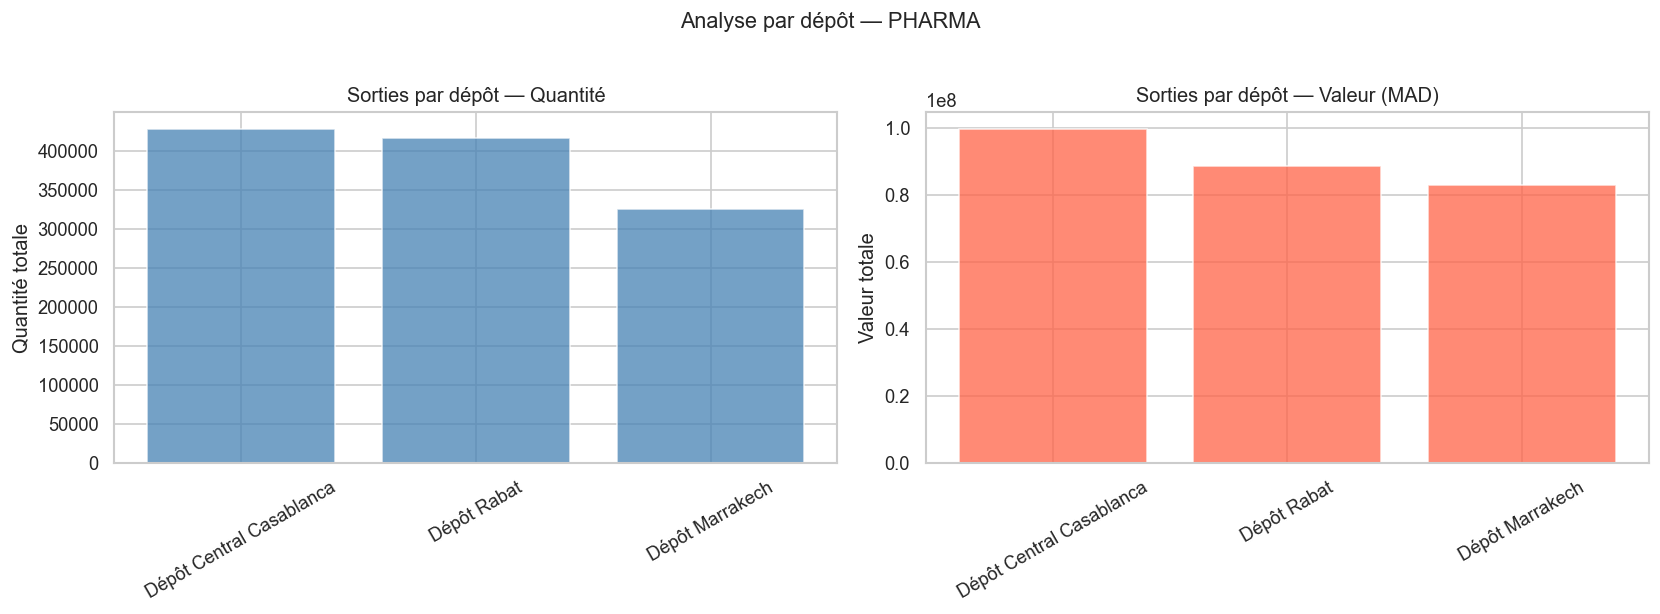

In [406]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(by_depot['DE_Intitule'], by_depot['TotalSortie'],
            color='steelblue', alpha=0.75)
axes[0].set_title("Sorties par dépôt — Quantité", fontsize=12)
axes[0].set_ylabel("Quantité totale")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(by_depot['DE_Intitule'], by_depot['ValeurSortie'],
            color='tomato', alpha=0.75)
axes[1].set_title("Sorties par dépôt — Valeur (MAD)", fontsize=12)
axes[1].set_ylabel("Valeur totale")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f"Analyse par dépôt — {BASE_NAME}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}analyse_depots.png")
plt.show()

In [407]:
# Cellule 14 — Corrélations

In [408]:
cols_corr = ['TotalEntree','TotalSortie','ValeurEntree','ValeurSortie','TotalValeurMouvement']
corr_matrix = df_mvt[cols_corr].corr().round(2)
corr_matrix

,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,TotalValeurMouvement
TotalEntree,1.00,0.06,0.87,0.04,0.86
TotalSortie,0.06,1.00,0.05,0.71,-0.04
ValeurEntree,0.87,0.05,1.00,0.08,0.99
ValeurSortie,0.04,0.71,0.08,1.00,-0.04
TotalValeurMouvement,0.86,-0.04,0.99,-0.04,1.00


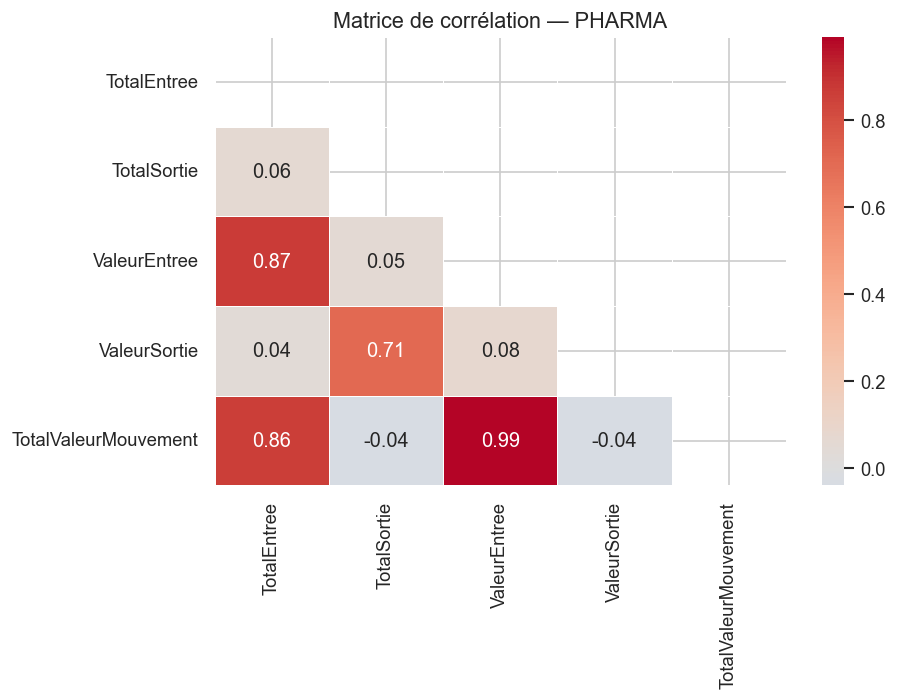

In [409]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title(f"Matrice de corrélation — {BASE_NAME}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}correlation_matrix.png")
plt.show()

,Lag (jours),Corrélation Entrée↔Sortie
0,0,0.105
1,1,-0.391
2,2,-0.046
3,3,-0.159
4,4,-0.058
5,5,0.059
6,6,-0.188
7,7,0.292


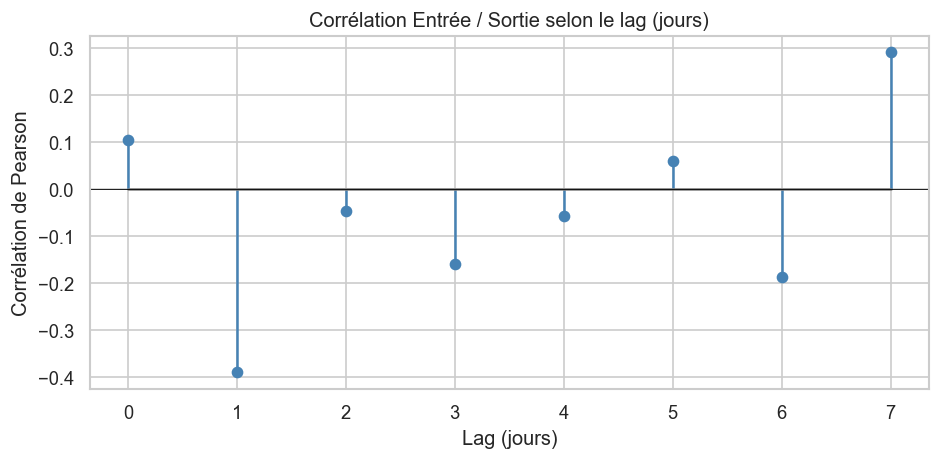

In [410]:
# ── Corrélation Entrée / Sortie par article (lag 0→7 jours) ──
lags = range(0, 8)
correlations = []

for lag in lags:
    df_lag = df_daily.copy()
    df_lag['Sortie_lag'] = df_lag['TotalSortie'].shift(lag)
    r = df_lag['TotalEntree'].corr(df_lag['Sortie_lag'])
    correlations.append({'Lag (jours)': lag, 'Corrélation Entrée↔Sortie': round(r, 3)})

df_lag_corr = pd.DataFrame(correlations)
display(df_lag_corr)

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(df_lag_corr['Lag (jours)'], df_lag_corr['Corrélation Entrée↔Sortie'],
        linefmt='steelblue', markerfmt='o', basefmt='gray')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title("Corrélation Entrée / Sortie selon le lag (jours)", fontsize=12)
ax.set_xlabel("Lag (jours)")
ax.set_ylabel("Corrélation de Pearson")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}correlation_lag_entree_sortie.png")
plt.show()

In [411]:
# Cellule 15 — Analyse du stock (depuis StockJournalierCache)

In [412]:
# ── Stock final moyen par article (top 20) ───────────────────
by_stock = df_stock.groupby(['AR_Ref','AR_Design']).agg(
    StockFinalMoyen  = ('StockFinal',   'mean'),
    StockFinalMax    = ('StockFinal',   'max'),
    StockFinalMin    = ('StockFinal',   'min'),
    ValeurFinaleMoy  = ('ValeurFinale', 'mean'),
    NbJours0         = ('StockFinal',   lambda x: (x == 0).sum())
).reset_index()

by_stock['% jours à zéro'] = (by_stock['NbJours0'] / df_stock['DateJour'].nunique() * 100).round(1)
by_stock = by_stock.sort_values('StockFinalMoyen', ascending=False)

print("Top 20 articles — Stock final moyen :")
by_stock.head(20)

Top 20 articles — Stock final moyen :


,AR_Ref,AR_Design,StockFinalMoyen,StockFinalMax,StockFinalMin,ValeurFinaleMoy,NbJours0,% jours à zéro
53,PH0054,Érythromycine 500mg,740.839774,1949.9810,58.9717,348161.898979,0,0.0
19,PH0020,Insuline Lente 100UI,735.680377,1864.0481,51.5619,163922.606891,0,0.0
7,PH0008,Aspirine 100mg,694.550379,1921.1084,0.0000,269177.645530,1,0.1
34,PH0035,Lopéramide 2mg,694.462154,1888.6489,18.8984,69329.216724,0,0.0
151,PH0152,Linézolide 600mg,690.669090,1871.3792,0.0000,334904.363067,1,0.1
149,PH0150,Ginseng Extrait,687.954522,1844.8474,49.0978,176228.270133,0,0.0
108,PH0109,Bromhexine 8mg,687.110433,1796.7036,30.4139,9681.881557,0,0.0
62,PH0063,Spironolactone 25mg,658.007743,1977.9036,54.0960,177178.406498,0,0.0
57,PH0058,Paracétamol+Codéine,633.560207,1703.7174,84.4749,15465.713509,0,0.0
116,PH0117,Répaglinide 1mg,631.834677,1858.5603,0.0000,76565.452664,3,0.3


In [413]:
# ── Articles à risque de rupture (>30% jours à stock=0) ──────
rupture_risk = by_stock[by_stock['% jours à zéro'] > 30]\
    .sort_values('% jours à zéro', ascending=False)

print(f"⚠️  Articles à risque de rupture (> 30% des jours à stock nul) : {len(rupture_risk)}")
rupture_risk[['AR_Ref','AR_Design','StockFinalMoyen','% jours à zéro']].head(20)

⚠️  Articles à risque de rupture (> 30% des jours à stock nul) : 0


,AR_Ref,AR_Design,StockFinalMoyen,% jours à zéro


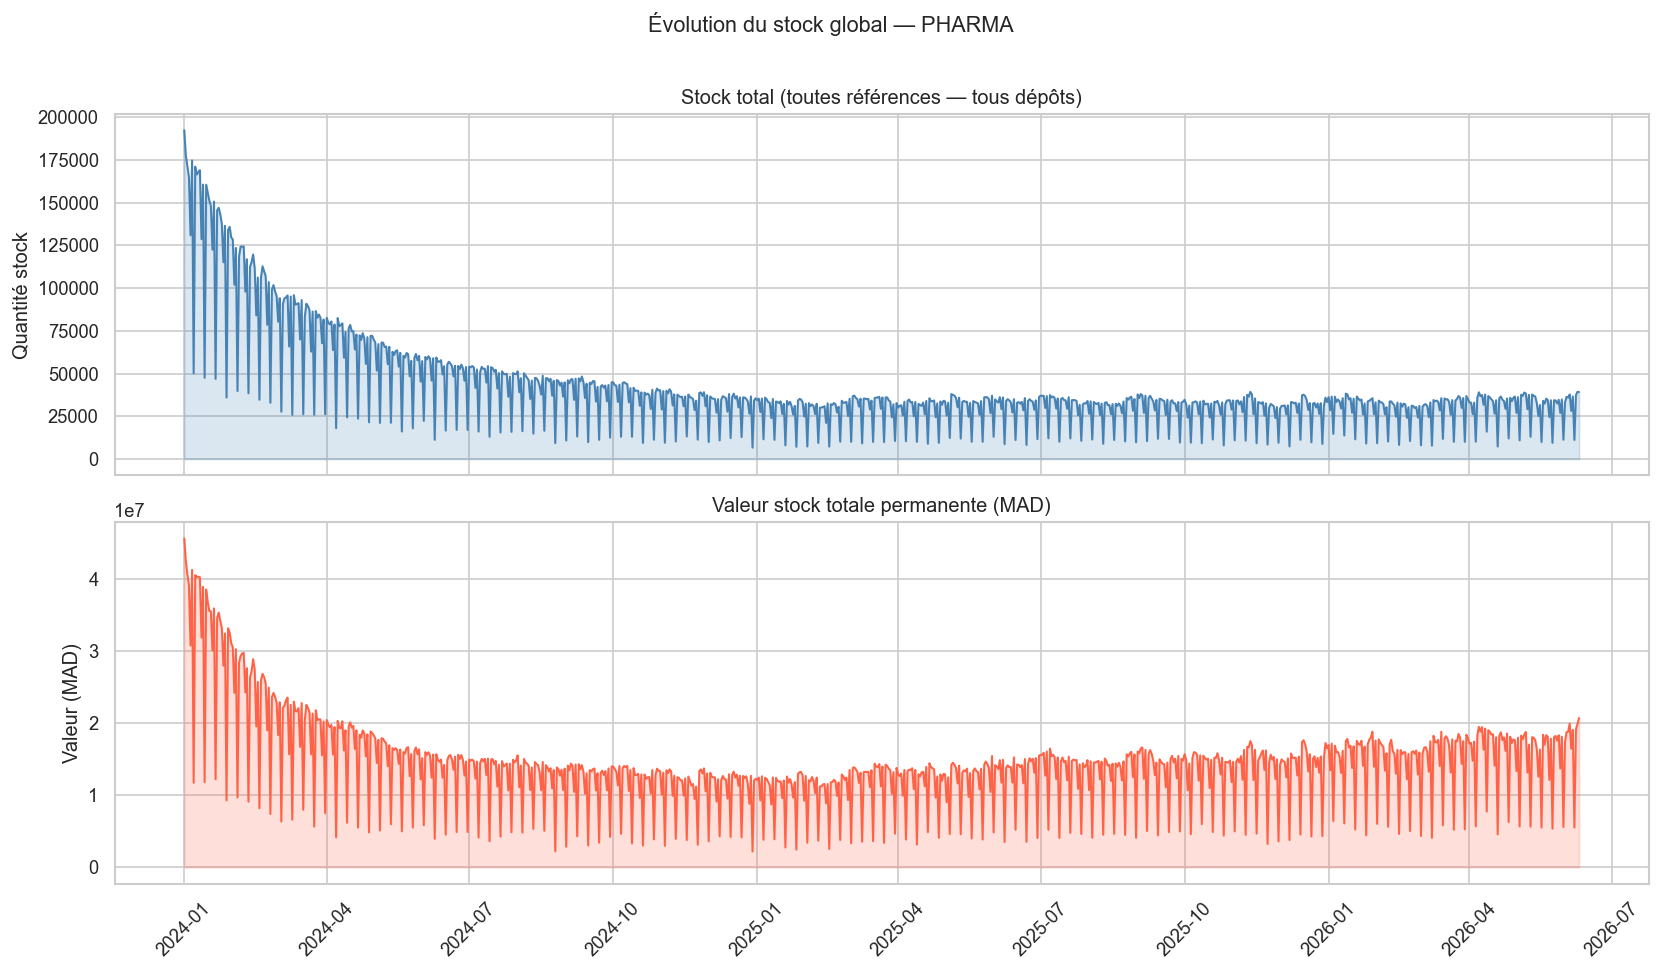

In [414]:
# ── Évolution stock global (somme StockFinal tous articles) ──
df_stock_global = df_stock.groupby('DateJour').agg(
    StockTotal   = ('StockFinal',   'sum'),
    ValeurTotale = ('ValeurFinale', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_stock_global['DateJour'], df_stock_global['StockTotal'],
             color='steelblue', linewidth=1.2)
axes[0].fill_between(df_stock_global['DateJour'], df_stock_global['StockTotal'],
                     alpha=0.2, color='steelblue')
axes[0].set_title("Stock total (toutes références — tous dépôts)", fontsize=12)
axes[0].set_ylabel("Quantité stock")

axes[1].plot(df_stock_global['DateJour'], df_stock_global['ValeurTotale'],
             color='tomato', linewidth=1.2)
axes[1].fill_between(df_stock_global['DateJour'], df_stock_global['ValeurTotale'],
                     alpha=0.2, color='tomato')
axes[1].set_title("Valeur stock totale permanente (MAD)", fontsize=12)
axes[1].set_ylabel("Valeur (MAD)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.suptitle(f"Évolution du stock global — {BASE_NAME}", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}evolution_stock_global.png")
plt.show()

In [415]:
# Cellule 16 — Analyse des doublons 

In [416]:
doublons = df_mvt.duplicated(subset=['DateJour','AR_Ref','DE_No']).sum()
print(f"Doublons (DateJour + AR_Ref + DE_No) : {doublons}")

Doublons (DateJour + AR_Ref + DE_No) : 0


In [417]:
# Cellule 17 — Continuité temporelle

In [418]:
all_dates = pd.date_range(df_mvt['DateJour'].min(), df_mvt['DateJour'].max())
dates_presentes = df_mvt['DateJour'].unique()
trous = [d for d in all_dates if d not in dates_presentes]
print(f"Jours sans aucun mouvement : {len(trous)}")
pd.DataFrame({'Date manquante': trous})

Jours sans aucun mouvement : 0


,Date manquante


In [419]:
# Cellule 19 — Distribution des articles par fréquence de sortie

In [420]:
freq = df_mvt[df_mvt['TotalSortie'] > 0]\
    .groupby('AR_Ref')['DateJour'].nunique()\
    .reset_index()\
    .rename(columns={'DateJour': 'NbJoursSortie'})

bins = [0, 10, 30, 90, 180, 365, 9999]
labels = ['< 10j', '10-30j', '30-90j', '90-180j', '180-365j', '> 365j']
freq['Segment'] = pd.cut(freq['NbJoursSortie'], bins=bins, labels=labels)

display(freq['Segment'].value_counts().reset_index()\
    .rename(columns={'index':'Segment fréquence','Segment':'Nb articles'}))

,Nb articles,count
0,> 365j,154
1,< 10j,0
2,10-30j,0
3,30-90j,0
4,90-180j,0
5,180-365j,0


In [421]:
# Cellule 20 —Concentration type Pareto 80/20

In [422]:
by_art_sorted = by_article.sort_values('TotalSortie', ascending=False).copy()
by_art_sorted['CumulPct'] = by_art_sorted['TotalSortie'].cumsum() / by_art_sorted['TotalSortie'].sum() * 100

seuil_80 = by_art_sorted[by_art_sorted['CumulPct'] <= 80]
print(f"Pareto : {len(seuil_80)} articles ({len(seuil_80)/len(by_art_sorted)*100:.1f}%) représentent 80% des sorties")

Pareto : 96 articles (62.3%) représentent 80% des sorties


In [423]:
# Cellule 21 — Résumé final et export

In [424]:
print("=" * 60)
print(f"  RÉSUMÉ EXPLORATION — {BASE_NAME}")
print("=" * 60)

print(f"""
📦 Données mouvements
   Lignes totales         : {len(df_mvt):,}
   Période                : {df_mvt['DateJour'].min().date()} → {df_mvt['DateJour'].max().date()}
   Nb articles distincts  : {df_mvt['AR_Ref'].nunique():,}
   Nb dépôts              : {df_mvt['DE_No'].nunique()}
   Nb familles            : {df_mvt['FA_CodeFamille'].nunique()}

📊 Valeurs manquantes
   Colonnes impactées     : {(df_mvt.isnull().sum() > 0).sum()}

⚠️  Outliers (méthode IQR)
   TotalSortie            : {len(detect_outliers_iqr(df_mvt, 'TotalSortie')[0]):,} lignes
   ValeurSortie           : {len(detect_outliers_iqr(df_mvt, 'ValeurSortie')[0]):,} lignes

🔴 Articles à risque rupture (>30% jours stock=0)
   Nb articles            : {len(rupture_risk)}

📁 Graphes exportés dans :
   {OUTPUT_DIR}
""")

  RÉSUMÉ EXPLORATION — PHARMA



📦 Données mouvements
   Lignes totales         : 101,512
   Période                : 2024-01-01 → 2026-06-10
   Nb articles distincts  : 154
   Nb dépôts              : 3
   Nb familles            : 10

📊 Valeurs manquantes
   Colonnes impactées     : 0

⚠️  Outliers (méthode IQR)
   TotalSortie            : 3,206 lignes
   ValeurSortie           : 7,104 lignes

🔴 Articles à risque rupture (>30% jours stock=0)
   Nb articles            : 0

📁 Graphes exportés dans :
   ..\..\output\PHARMA\exploration



In [425]:
# ── Export résumé CSV ─────────────────────────────────────────
by_article.to_csv(f"{OUTPUT_DIR}resume_articles.csv", index=False)
by_famille.to_csv(f"{OUTPUT_DIR}resume_familles.csv", index=False)
rupture_risk.to_csv(f"{OUTPUT_DIR}articles_risque_rupture.csv", index=False)

print("✅ Fichiers CSV exportés")

conn.close()
print("✅ Connexion SQL fermée")

✅ Fichiers CSV exportés
✅ Connexion SQL fermée
